# CODIGO EJECUTADO EN COLAB

In [3]:
with open("/content/data/raw/4 July 2018 Dataset/6P70A06R1.dat") as f:
    for i in range(len("/content/data/raw/4 July 2018 Dataset/6P70A06R1.dat")):
        print(f.readline().strip())

5800000000.000000
1.000000
128
400000000.000000
1599+2095i
2026+2082i
2046+2091i
2023+1487i
2205+1690i
2230+1759i
2247+1834i
2234+1939i
2178+2000i
2109+1990i
2088+1939i
2113+1938i
2121+1997i
2092+2009i
2083+1983i
2104+2026i
2034+2043i
2018+1998i
2025+1979i
2018+1977i
2019+1940i
2070+1950i
2089+2005i
2068+2071i
2031+2125i
1941+2099i
1880+2020i
1855+1946i
1855+1830i
1930+1711i
2039+1683i
2170+1749i
2267+1907i
2238+2084i
2174+2172i
2068+2190i
1961+2148i
1936+1973i
1992+1925i
2082+1978i
2085+2082i
2031+2107i
1974+2130i
1920+2046i
1913+1975i
1901+1936i
1945+1880i


In [4]:
with open("/content/data/raw/4 July 2018 Dataset/6P70A06R1.dat") as f:

  print(f.readline())


5800000000.000000



In [5]:
import numpy as np

def cargar_ruta(ruta):
  with open(ruta) as f:
      lineas = f.readlines()

      params = {
          "fc":   float(lineas[0]),
          "t_chirp":    float(lineas[1]),
          "n_muestras": int(lineas[2]),
          "bw":         float(lineas[3])
      }

      datos = []

      for complejo in lineas[4:]:
        complejo = complejo.strip()
        complejo = complejo.replace("i", "j")
        complejo = complex(complejo)
        datos.append(complejo)
      datos = np.array(datos)

  n = params["n_muestras"]
  assert len(datos) % n == 0, f"{ruta}: {len(datos)} datos, no es múltiplo de {n}"
  datos = datos.reshape((n, -1), order="F")

  return params, datos


In [6]:
%%time
RUTA = "/content/data/raw/4 July 2018 Dataset/6P70A06R1.dat"

params, datos = cargar_ruta(RUTA)
print(datos.dtype, datos.shape)

complex128 (128, 5000)
CPU times: user 401 ms, sys: 40.7 ms, total: 442 ms
Wall time: 461 ms


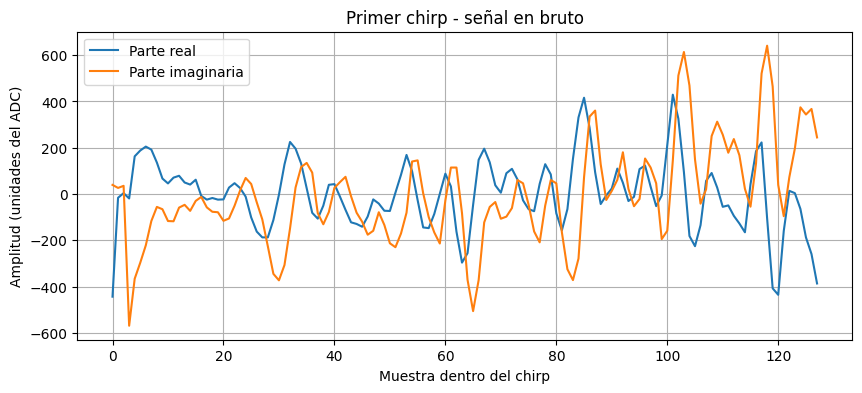

Media de todos los datos: (-9.822542779147625e-14-2.3283064365386963e-13j)


In [7]:
import matplotlib.pyplot as plt

chirp = datos[:, 0]

datos_sin_dc = datos - np.mean(datos)
chirp = datos_sin_dc[:, 0]

plt.figure(figsize=(10, 4))
plt.plot(chirp.real, label="Parte real")
plt.plot(chirp.imag, label="Parte imaginaria")
plt.xlabel("Muestra dentro del chirp")
plt.ylabel("Amplitud (unidades del ADC)")
plt.title("Primer chirp - señal en bruto")
plt.legend()
plt.grid(True)
plt.show()

print("Media de todos los datos:", np.mean(datos_sin_dc))

In [36]:
import re

def resolucion_distancia(bw):
    return 3e8 / (2 * bw)

def fft_distancia(datos):
  return np.fft.fft(datos, axis=0)

def elim_offset(datos):
  return datos - np.mean(datos)

def filtro_mti(perfil):
  return perfil - np.mean(perfil, axis=1, keepdims=True)

def detectar_rango(perfil_mti, margen_db=10, salto=2):

  salto_der = salto_izq = True

  potencia = np.abs(perfil_mti) ** 2

  energia = np.sum(potencia, axis=1)
  energia_db = 10 * np.log10(energia)
  umbral = np.median(energia_db) + margen_db

  semilla = np.argmax(energia_db)

  izquierda = semilla
  derecha = semilla

  while izquierda - 1 >= 0 and (energia_db[izquierda - 1] > umbral or salto_izq):

    if energia_db[izquierda - 1] < umbral:
      salto_izq = False
      destino = max(0, izquierda - salto)

      if energia_db[destino] > umbral:
        izquierda = destino
      else:
        break
    else:
      izquierda -= 1


  while derecha + 1 < len(energia_db) and (energia_db[derecha + 1] > umbral or salto_der):

    if energia_db[derecha + 1] < umbral:
      salto_der = False
      destino = min(len(energia_db) - 1, derecha + salto)

      if energia_db[destino] > umbral:
        derecha = destino
      else:
        break
    else:
      derecha += 1

  return izquierda, derecha

ACTIVIDADES = {1: "andar", 2: "sentarse", 3: "levantarse",
               4: "agacharse", 5: "beber", 6: "caerse"}

def actividad_desde_ruta(ruta):
    nombre = os.path.basename(ruta)
    return int(nombre[0])

def senal_temporal(perfil_mti, izquierda, derecha):
  return np.sum(perfil_mti[izquierda:derecha + 1, :], axis=0)

def procesar_perfil(datos):
    perfil = fft_distancia(elim_offset(datos))
    perfil = perfil[: perfil.shape[0] // 2]
    return filtro_mti(perfil)

_PATRON = re.compile(r"(\d)P(\d+)A(\d+)R(\d+)", re.IGNORECASE)

def parsear_nombre(ruta):
    nombre = os.path.basename(ruta)
    m = _PATRON.match(nombre)
    if m is None:
        raise ValueError(f"Nombre no reconocido: {nombre}")
    actividad, persona, _, repeticion = map(int, m.groups())
    return {
        "actividad": actividad,
        "persona": persona,
        "repeticion": repeticion,
        "campana": os.path.basename(os.path.dirname(ruta)),
    }

[[-2.54010000e+01 -766.432j      -1.54010000e+01 -751.432j
  -2.54010000e+01 -762.432j      ...  1.75990000e+01 +147.568j
   1.85990000e+01 +163.568j      -2.40100000e+00 +117.568j     ]
 [-8.06360649e+03+7204.28684338j -8.05189085e+03+7199.36546399j
  -8.05637077e+03+7193.07025732j ... -8.25106468e+03+7109.37453546j
  -8.25581089e+03+7114.58437839j -8.23747559e+03+7094.22185588j]
 [-8.12776930e+03-5129.15996109j -8.12052110e+03-5139.4538903j
  -8.12534535e+03-5118.97733991j ... -7.23130395e+03-3676.48923236j
  -7.19628573e+03-3658.05150707j -7.20644323e+03-3665.88950744j]
 ...
 [ 1.98798661e+03+1822.98351893j  1.98169818e+03+1847.96412367j
   1.99472324e+03+1842.48592394j ...  6.96842067e+02+2292.93924502j
   6.40627738e+02+2285.88349384j  6.60949122e+02+2292.81077929j]
 [ 3.38709960e+03+1461.50815784j  3.38305832e+03+1461.60893077j
   3.39249844e+03+1477.79745265j ...  1.82110225e+03+2462.01501356j
   1.81396060e+03+2497.55484844j  1.82182363e+03+2473.31008276j]
 [ 5.42459977e+03+369

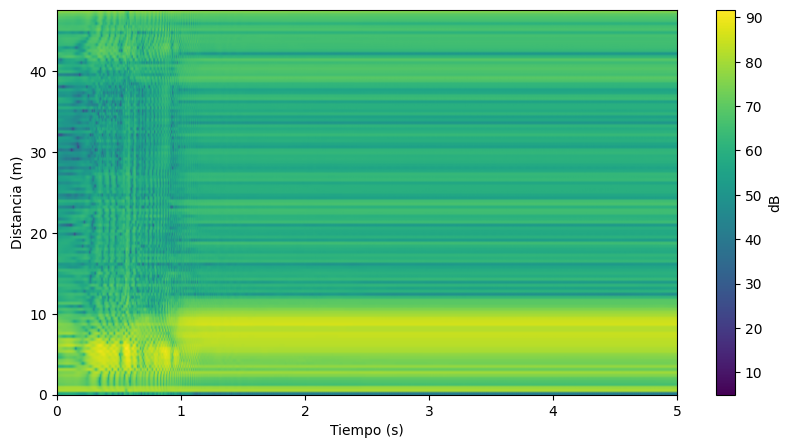

In [9]:
datos_sin_dc = elim_offset(datos)
perfil = fft_distancia(datos_sin_dc)

print(perfil)

res = resolucion_distancia(params["bw"])
eje_distancia = np.arange(perfil.shape[0]) * res

perfil_db = 20 * np.log10(np.abs(perfil))
t_max = perfil.shape[1] * params["t_chirp"] / 1000

plt.figure(figsize=(10, 5))
plt.imshow(perfil_db, aspect="auto", origin="lower",
           extent=[0, t_max, 0, eje_distancia[-1]])
plt.xlabel("Tiempo (s)")
plt.ylabel("Distancia (m)")
plt.colorbar(label="dB")
plt.show()

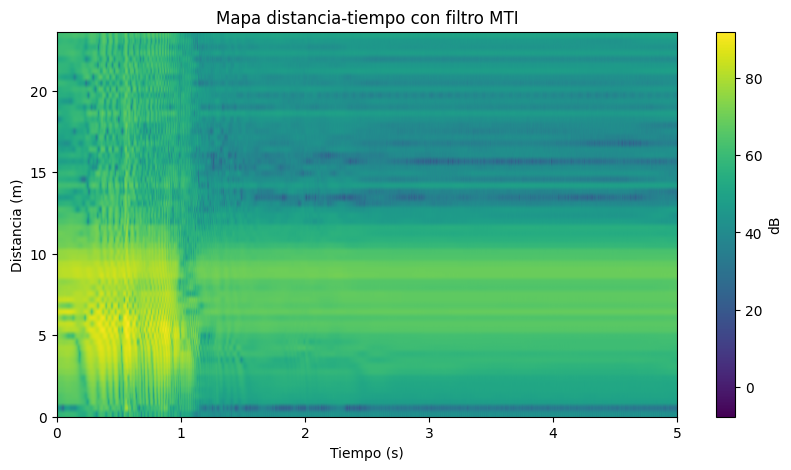

In [10]:
datos_sin_dc = elim_offset(datos)
perfil = fft_distancia(datos_sin_dc)
perfil = perfil[: perfil.shape[0] // 2]
perfil_mti = filtro_mti(perfil)

res = resolucion_distancia(params["bw"])
eje_distancia = np.arange(perfil_mti.shape[0]) * res
t_max = perfil_mti.shape[1] * params["t_chirp"] / 1000

perfil_db = 20 * np.log10(np.abs(perfil_mti))

plt.figure(figsize=(10, 5))
plt.imshow(perfil_db, aspect="auto", origin="lower",
           extent=[0, t_max, 0, eje_distancia[-1]])
plt.xlabel("Tiempo (s)")
plt.ylabel("Distancia (m)")
plt.colorbar(label="dB")
plt.title("Mapa distancia-tiempo con filtro MTI")
plt.show()

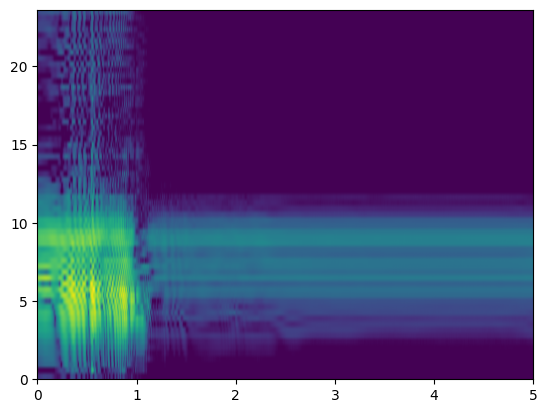

In [11]:
vmax = perfil_db.max()
plt.imshow(perfil_db, aspect="auto", origin="lower",
           extent=[0, t_max, 0, eje_distancia[-1]],
           vmin=vmax - 40, vmax=vmax)

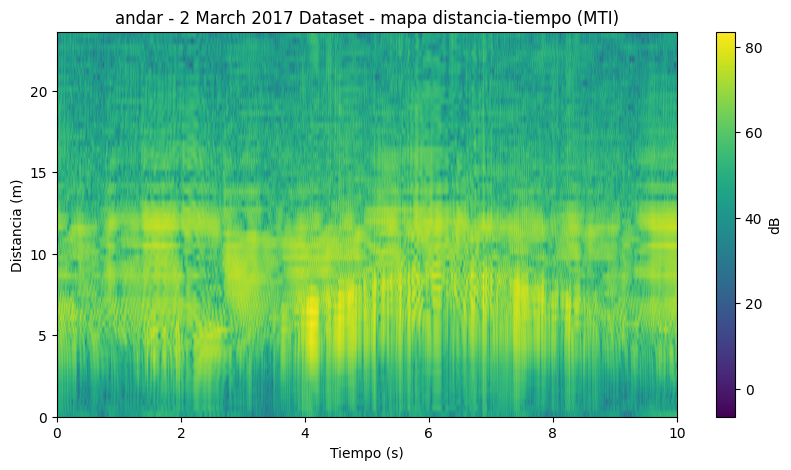

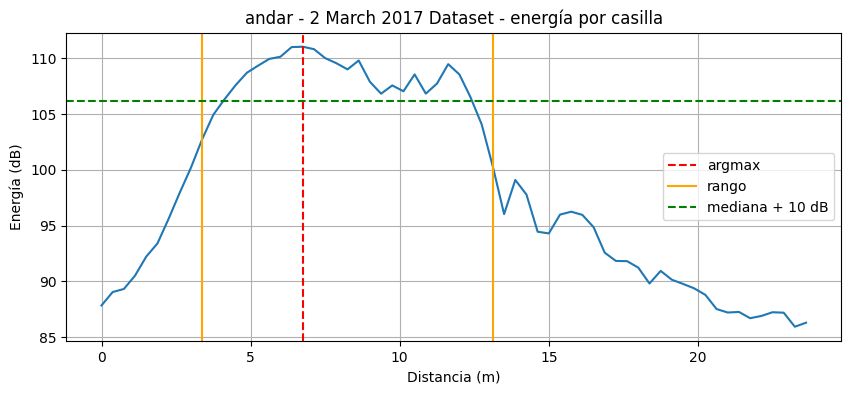

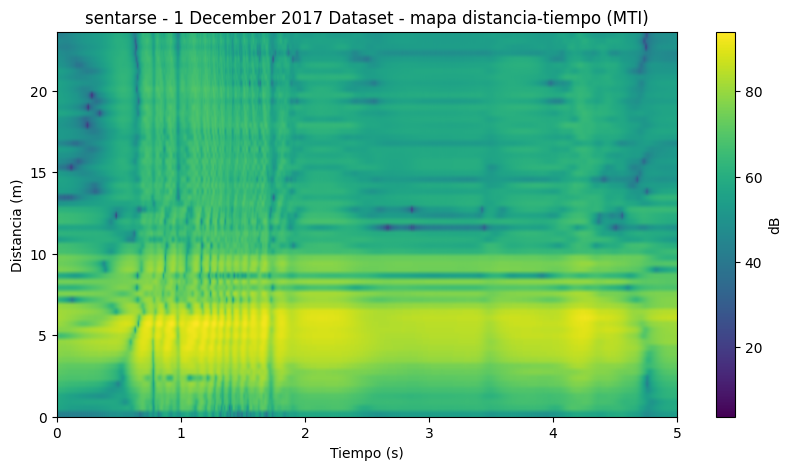

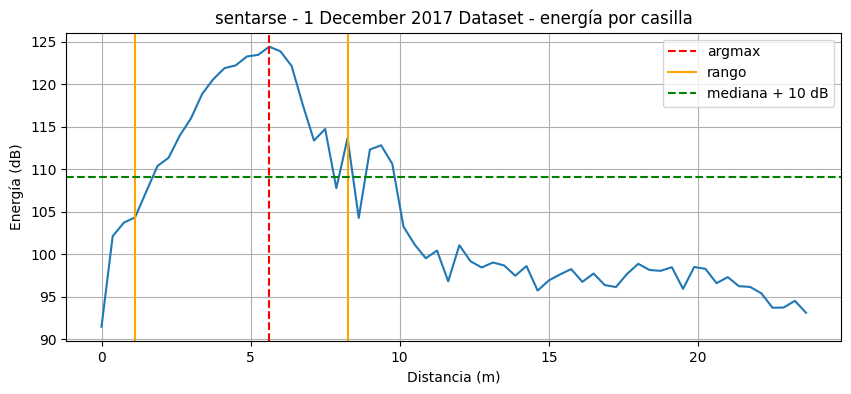

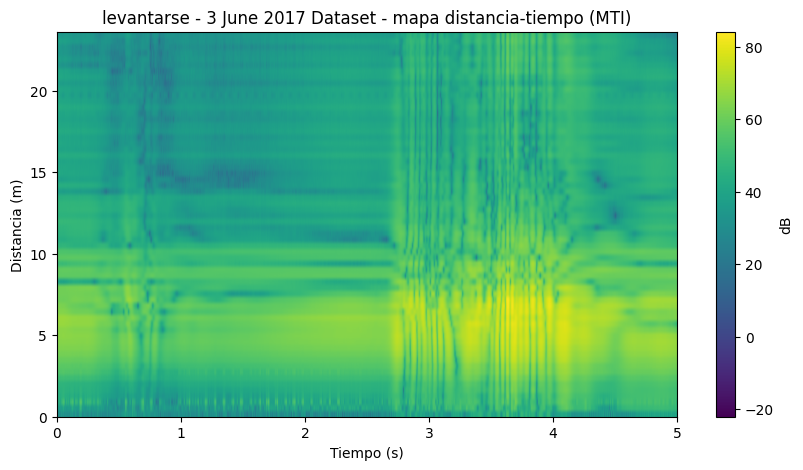

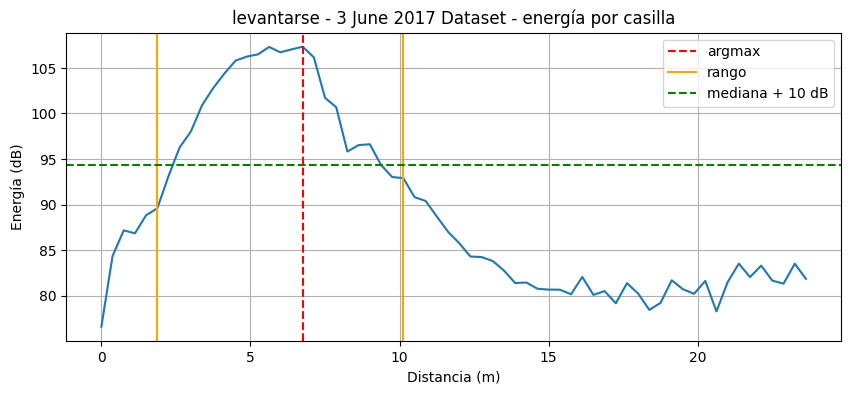

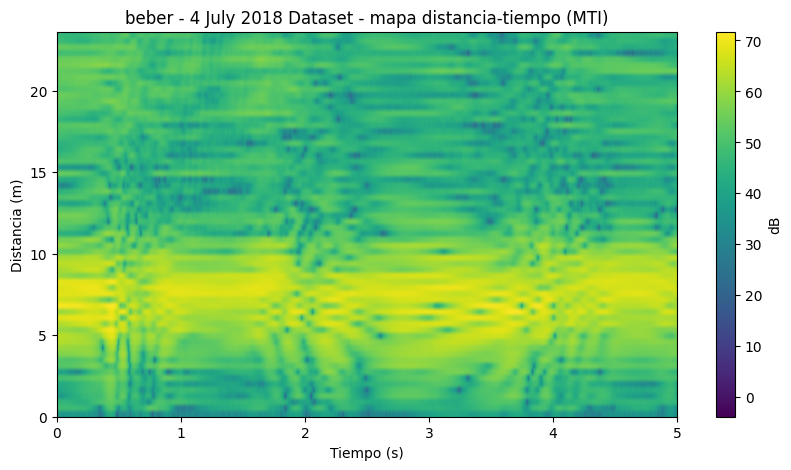

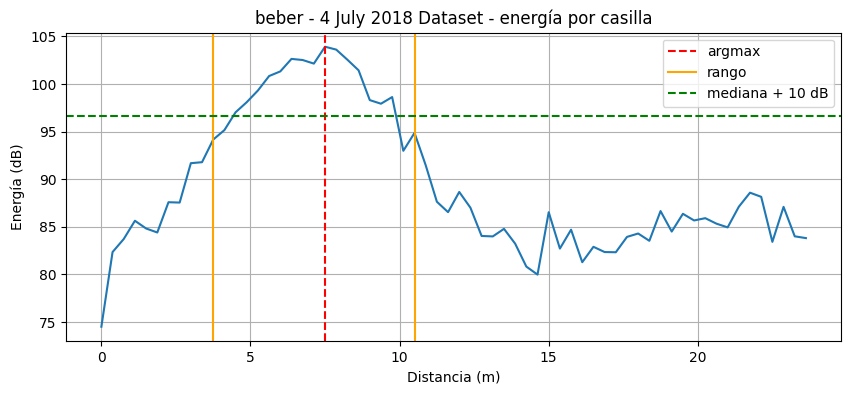

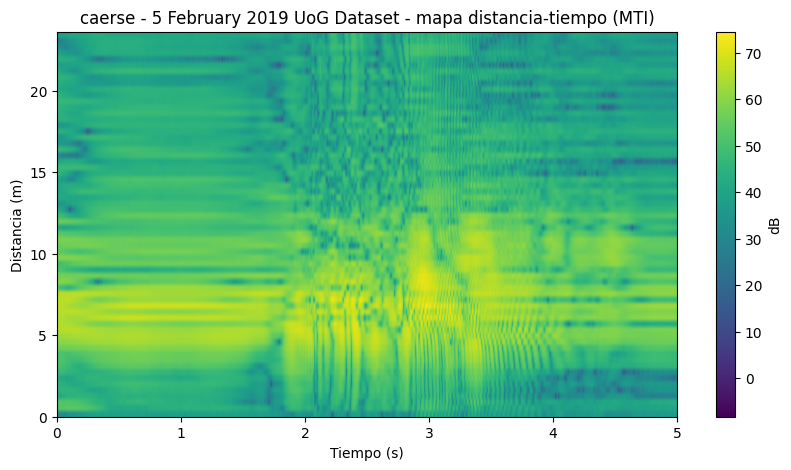

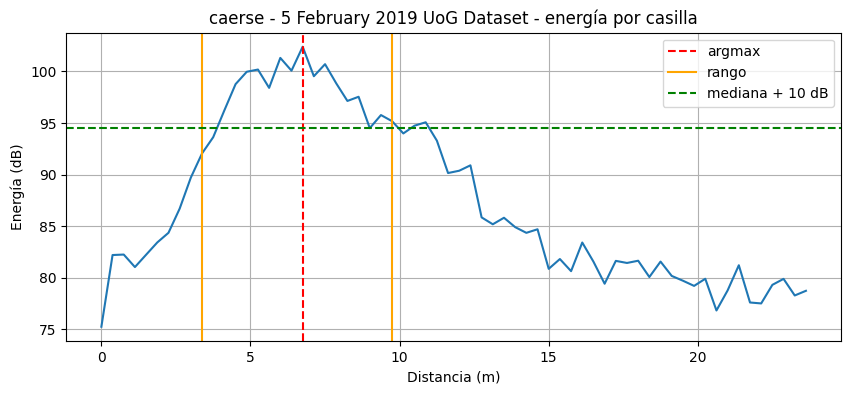

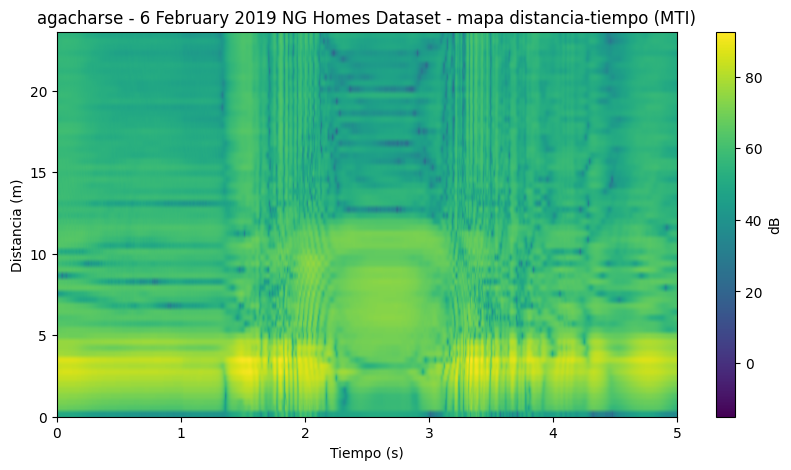

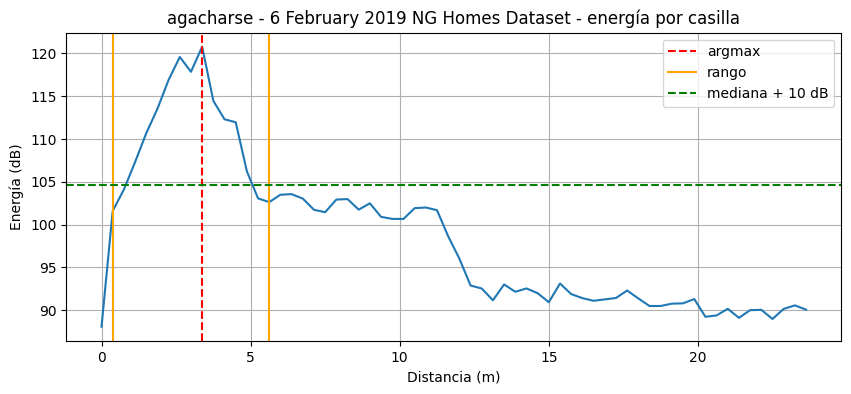

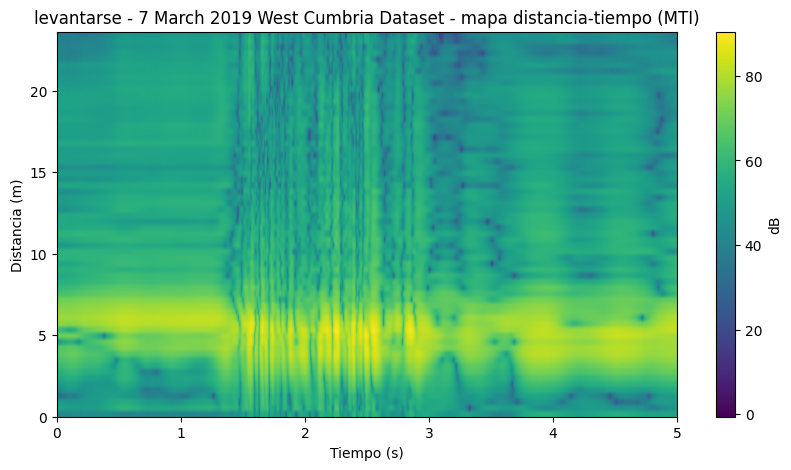

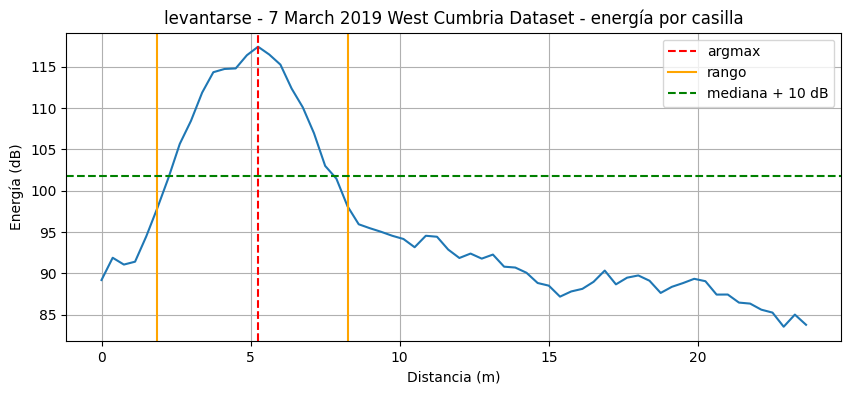

In [20]:

rutas = ["/content/data/raw/2 March 2017 Dataset/1P11A01R1.dat" ,"/content/data/raw/1 December 2017 Dataset/2P45A02R02.dat",
"/content/data/raw/3 June 2017 Dataset/3P35A03R1.dat" ,"/content/data/raw/4 July 2018 Dataset/5P62A05R3.dat",
"/content/data/raw/5 February 2019 UoG Dataset/6P15A06R03.dat", "/content/data/raw/6 February 2019 NG Homes Dataset/4P08A04R3.dat",
"/content/data/raw/7 March 2019 West Cumbria Dataset/3P41A03R3.dat"
]
for ruta in rutas:

  act = actividad_desde_ruta(ruta)
  sesion = os.path.basename(os.path.dirname(ruta))
  titulo = f"{ACTIVIDADES[act]} - {sesion}"

  params, datos = cargar_ruta(ruta)

  datos_sin_dc = elim_offset(datos)
  perfil = fft_distancia(datos_sin_dc)
  perfil = perfil[: perfil.shape[0] // 2]
  perfil_mti = filtro_mti(perfil)

  res = resolucion_distancia(params["bw"])
  eje_distancia = np.arange(perfil_mti.shape[0]) * res
  t_max = perfil_mti.shape[1] * params["t_chirp"] / 1000

  perfil_db = 20 * np.log10(np.abs(perfil_mti))

  plt.figure(figsize=(10, 5))
  plt.imshow(perfil_db, aspect="auto", origin="lower",
            extent=[0, t_max, 0, eje_distancia[-1]])
  plt.xlabel("Tiempo (s)")
  plt.ylabel("Distancia (m)")
  plt.colorbar(label="dB")
  plt.title(f"{titulo} - mapa distancia-tiempo (MTI)")
  plt.show()

  potencia = np.abs(perfil_mti) ** 2
  energia = np.sum(potencia, axis=1)
  energia_db = 10 * np.log10(energia)

  casilla_pico = np.argmax(energia_db)
  umbral = np.median(energia_db) + 10

  casilla_min, casilla_max = detectar_rango(perfil_mti)

  plt.figure(figsize=(10, 4))
  plt.plot(eje_distancia, energia_db)
  plt.axvline(casilla_pico * res, color="red", linestyle="--", label="argmax")
  plt.axvline(casilla_min * res, color="orange", label="rango")
  plt.axvline(casilla_max * res, color="orange")
  plt.axhline(umbral, color="green", linestyle="--", label="mediana + 10 dB")
  plt.xlabel("Distancia (m)"); plt.ylabel("Energía (dB)")
  plt.title(f"{titulo} - energía por casilla")
  plt.legend(); plt.grid(True); plt.show()


In [21]:
casilla_min, casilla_max = detectar_rango(perfil_mti)
print(casilla_min, casilla_max)
print(casilla_min * res, "m -", casilla_max * res, "m")

5 22
1.875 m - 8.25 m


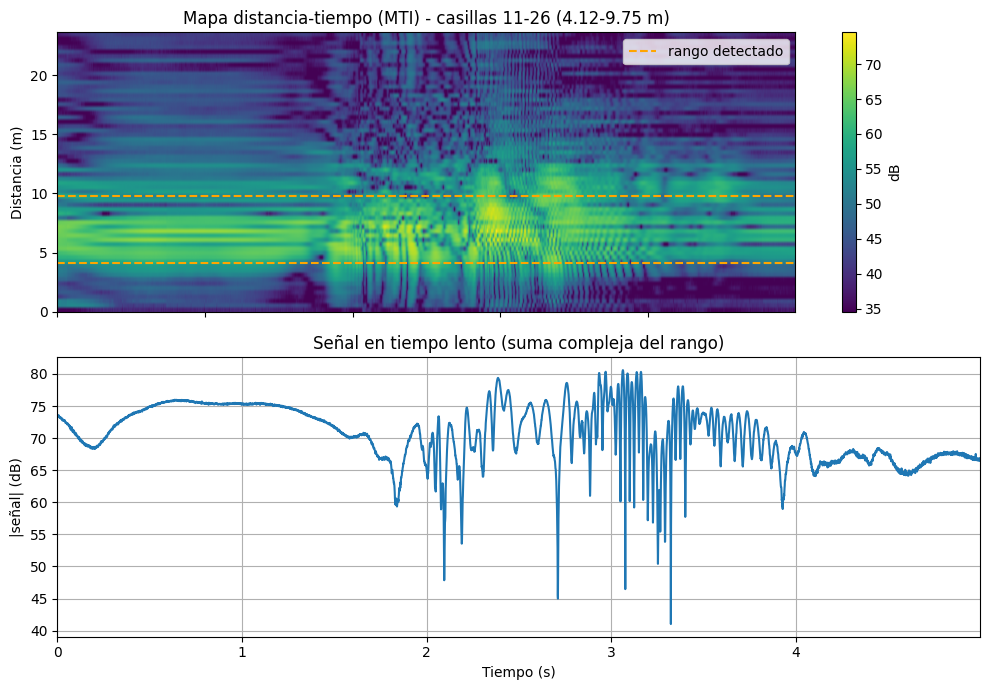

complex128 (5000,)


In [26]:

ruta = "/content/data/raw/5 February 2019 UoG Dataset/6P15A06R03.dat"

params, datos = cargar_ruta(ruta)

datos_sin_dc = elim_offset(datos)
perfil = fft_distancia(datos_sin_dc)
perfil = perfil[: perfil.shape[0] // 2]
perfil_mti = filtro_mti(perfil)

izq, der = detectar_rango(perfil_mti)

senal = senal_temporal(perfil_mti, izq, der)

res = resolucion_distancia(params["bw"])
eje_distancia = np.arange(perfil_mti.shape[0]) * res
eje_tiempo = np.arange(perfil_mti.shape[1]) * params["t_chirp"] / 1000   # s
t_max = eje_tiempo[-1]

perfil_db = 20 * np.log10(np.abs(perfil_mti))
vmax = perfil_db.max()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# 1) Mapa distancia-tiempo + rango detectado
im = ax1.imshow(perfil_db, aspect="auto", origin="lower",
                extent=[0, t_max, 0, eje_distancia[-1]],
                vmin=vmax - 40, vmax=vmax)
ax1.axhline(izq * res, color="orange", linestyle="--", label="rango detectado")
ax1.axhline(der * res, color="orange", linestyle="--")
ax1.set_ylabel("Distancia (m)")
ax1.set_title(f"Mapa distancia-tiempo (MTI) - casillas {izq}-{der} "
              f"({izq*res:.2f}-{der*res:.2f} m)")
ax1.legend(loc="upper right")
fig.colorbar(im, ax=ax1, label="dB")

# 2) Amplitud de la señal temporal
ax2.plot(eje_tiempo, 20 * np.log10(np.abs(senal)))
ax2.set_xlabel("Tiempo (s)")
ax2.set_ylabel("|señal| (dB)")
ax2.set_title("Señal en tiempo lento (suma compleja del rango)")
ax2.grid(True)

plt.tight_layout()
plt.show()

print(senal.dtype, senal.shape)


In [27]:
from google.colab import drive
import os

drive.mount("/content/drive")

SALIDA = "/content/drive/MyDrive/radar-micro-Doppler/processed"
CARPETA_SENALES = os.path.join(SALIDA, "senales")
os.makedirs(CARPETA_SENALES, exist_ok=True)

Mounted at /content/drive


In [28]:
import glob

rutas = sorted(glob.glob("/content/data/raw/*/*.dat"))

1754
['/content/data/raw/1 December 2017 Dataset/1P36A01R01.dat', '/content/data/raw/1 December 2017 Dataset/1P36A01R02.dat', '/content/data/raw/1 December 2017 Dataset/1P36A01R03.dat']


In [29]:
def id_grabacion(ruta):
    campana = os.path.basename(os.path.dirname(ruta)).split()[0]
    nombre = os.path.splitext(os.path.basename(ruta))[0]
    return f"C{campana}_{nombre}"

print(id_grabacion(rutas[0]))

C1_1P36A01R01


In [32]:
import numpy as np

ruta = rutas[0]

params, datos = cargar_ruta(ruta)
perfil_mti = procesar_perfil(datos)
izq, der = detectar_rango(perfil_mti)
senal = senal_temporal(perfil_mti, izq, der)

destino = os.path.join(CARPETA_SENALES, f"{id_grabacion(ruta)}.npz")
np.savez(destino,
         senal=senal.astype(np.complex64),
         izq=izq, der=der,
         fc=params["fc"], t_chirp=params["t_chirp"],
         bw=params["bw"], n_muestras=params["n_muestras"])

print("Guardado en:", destino)

Guardado en: /content/drive/MyDrive/radar-micro-Doppler/processed/senales/C1_1P36A01R01.npz


In [33]:
z = np.load(destino)
print(z.files)                      # ['senal', 'izq', 'der', 'fc', ...]
print(z["senal"].dtype, z["senal"].shape, int(z["izq"]), int(z["der"]))

['senal', 'izq', 'der', 'fc', 't_chirp', 'bw', 'n_muestras']
complex64 (10000,) 6 24


In [34]:
errores = []

for i, ruta in enumerate(rutas):
    destino = os.path.join(CARPETA_SENALES, f"{id_grabacion(ruta)}.npz")

    if os.path.exists(destino):
        continue

    try:
        params, datos = cargar_ruta(ruta)
        perfil_mti = procesar_perfil(datos)
        izq, der = detectar_rango(perfil_mti)
        senal = senal_temporal(perfil_mti, izq, der)

        np.savez(destino,
                 senal=senal.astype(np.complex64),
                 izq=izq, der=der,
                 fc=params["fc"], t_chirp=params["t_chirp"],
                 bw=params["bw"], n_muestras=params["n_muestras"])
    except Exception as e:
        errores.append((ruta, repr(e)))

    if (i + 1) % 100 == 0:
        print(f"{i + 1}/{len(rutas)}")

print(f"Terminado")

100/1754
200/1754
300/1754
400/1754
500/1754
600/1754
700/1754
800/1754
900/1754
1000/1754
1100/1754
1200/1754
1300/1754
1400/1754
1500/1754
1600/1754
1700/1754
Terminado


In [37]:
import pandas as pd

filas = []
for ruta_npz in sorted(glob.glob(os.path.join(CARPETA_SENALES, "*.npz"))):
    gid = os.path.splitext(os.path.basename(ruta_npz))[0]
    campana, nombre = gid.split("_", 1)
    meta = parsear_nombre(nombre)

    with np.load(ruta_npz) as z:
        filas.append({
            "id": gid,
            "campana": int(campana[1:]),
            "actividad": meta["actividad"],
            "persona": meta["persona"],
            "repeticion": meta["repeticion"],
            "izq": int(z["izq"]),
            "der": int(z["der"]),
            "n_chirps": len(z["senal"]),
            "t_chirp": float(z["t_chirp"]),
        })

df = pd.DataFrame(filas)
df.to_csv(os.path.join(SALIDA, "metadatos.csv"), index=False)
df.head()

,id,campana,actividad,persona,repeticion,izq,der,n_chirps,t_chirp
0,C1_1P36A01R01,1,1,36,1,6,24,10000,1.0
1,C1_1P36A01R02,1,1,36,2,6,23,10000,1.0
2,C1_1P36A01R03,1,1,36,3,7,23,10000,1.0
3,C1_1P37A01R01,1,1,37,1,5,24,10000,1.0
4,C1_1P37A01R02,1,1,37,2,5,23,10000,1.0


In [38]:
print(errores[:5])
print(len(df))
print(df.groupby("actividad").size())
print(df.groupby("campana").size())
print(df["n_chirps"].value_counts())

[]
1754
actividad
1    312
2    312
3    311
4    311
5    310
6    198
dtype: int64
campana
1    360
2     48
3    162
4    288
5    306
6    301
7    289
dtype: int64
n_chirps
5000     1441
10000     305
20000       8
Name: count, dtype: int64
